# Insurance Charges Risk Analysis

## Project Goal

The goal of this project is to analyze medical insurance charges and identify which patient factors are most associated with higher costs. This report focuses on smoking status, BMI category, age group, region, sex, and number of children.

The main business question is:

> What factors are most strongly connected to higher insurance charges, and what actions could reduce or better manage those cost drivers?

## Questions This Report Answers

- Do smokers pay higher insurance charges than non-smokers?
- Do charges increase across BMI categories?
- Do charges increase with age group?
- Which regions have higher average charges?
- What recommendations can help address the factors linked to higher charges?

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_DIR = Path("data")
CLEAN_PATH = DATA_DIR / "insurance_clean.csv"
DB_PATH = DATA_DIR / "insurance.db"

df = pd.read_csv(CLEAN_PATH)
df.head()

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category,is_smoker,is_obese,charge_level
0,19,female,27.900,0,yes,southwest,16884.92400,18-25,Overweight,1,0,High
1,18,male,33.770,1,no,southeast,1725.55230,18-25,Obese,0,1,Low
2,28,male,33.000,3,no,southeast,4449.46200,26-35,Obese,0,1,Low
3,33,male,22.705,0,no,northwest,21984.47061,26-35,Healthy,0,0,High
4,32,male,28.880,0,no,northwest,3866.85520,26-35,Overweight,0,0,Low


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1337 non-null   int64  
 1   sex           1337 non-null   str    
 2   bmi           1337 non-null   float64
 3   children      1337 non-null   int64  
 4   smoker        1337 non-null   str    
 5   region        1337 non-null   str    
 6   charges       1337 non-null   float64
 7   age_group     1337 non-null   str    
 8   bmi_category  1337 non-null   str    
 9   is_smoker     1337 non-null   int64  
 10  is_obese      1337 non-null   int64  
 11  charge_level  1337 non-null   str    
dtypes: float64(2), int64(4), str(6)
memory usage: 125.5 KB


In [3]:
df.describe().round(2)

,age,bmi,children,charges,is_smoker,is_obese
count,1337.00,1337.00,1337.00,1337.00,1337.0,1337.00
mean,39.22,30.66,1.10,13279.12,0.2,0.53
std,14.04,6.10,1.21,12110.36,0.4,0.50
min,18.00,15.96,0.00,1121.87,0.0,0.00
25%,27.00,26.29,0.00,4746.34,0.0,0.00
50%,39.00,30.40,1.00,9386.16,0.0,1.00
75%,51.00,34.70,2.00,16657.72,0.0,1.00
max,64.00,53.13,5.00,63770.43,1.0,1.00


## Key Metrics

In [4]:
print(f"Total customers: {len(df):,}")
print(f"Average charge: ${df['charges'].mean():,.2f}")
print(f"Median charge: ${df['charges'].median():,.2f}")
print(f"Minimum charge: ${df['charges'].min():,.2f}")
print(f"Maximum charge: ${df['charges'].max():,.2f}")

Total customers: 1,337
Average charge: $13,279.12
Median charge: $9,386.16
Minimum charge: $1,121.87
Maximum charge: $63,770.43


## Charges by Smoker Status

In [5]:
smoker_summary = (
    df.groupby("smoker")["charges"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

smoker_summary

,count,mean,median,min,max
smoker,,,,,
no,1063,8440.66,7345.73,1121.87,36910.61
yes,274,32050.23,34456.35,12829.46,63770.43


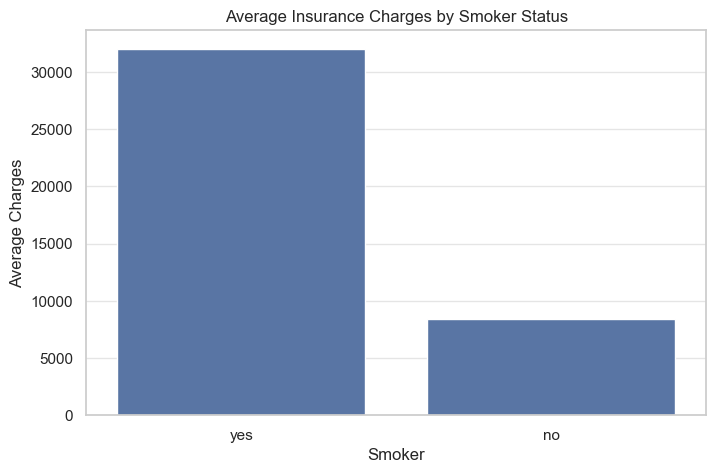

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="smoker", y="charges", estimator="mean", errorbar=None)
plt.title("Average Insurance Charges by Smoker Status")
plt.xlabel("Smoker")
plt.ylabel("Average Charges")
plt.show()

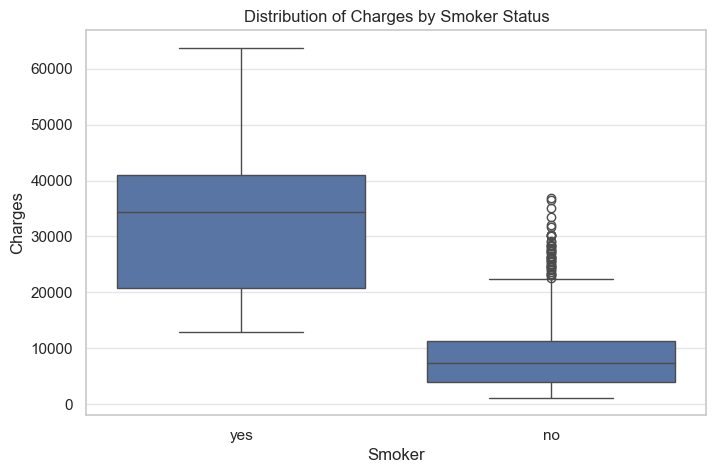

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Distribution of Charges by Smoker Status")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

## Charges by BMI Category

In [8]:
bmi_order = ["Underweight", "Healthy", "Overweight", "Obese"]

bmi_summary = (
    df.groupby("bmi_category", observed=False)["charges"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
    .reindex(bmi_order)
)

bmi_summary

,count,mean,median,min,max
bmi_category,,,,,
Underweight,21,8657.62,6640.54,1621.34,32734.19
Healthy,226,10435.44,8604.15,1121.87,35069.37
Overweight,386,10997.80,8659.38,1252.41,38245.59
Obese,704,15580.70,10003.65,1131.51,63770.43


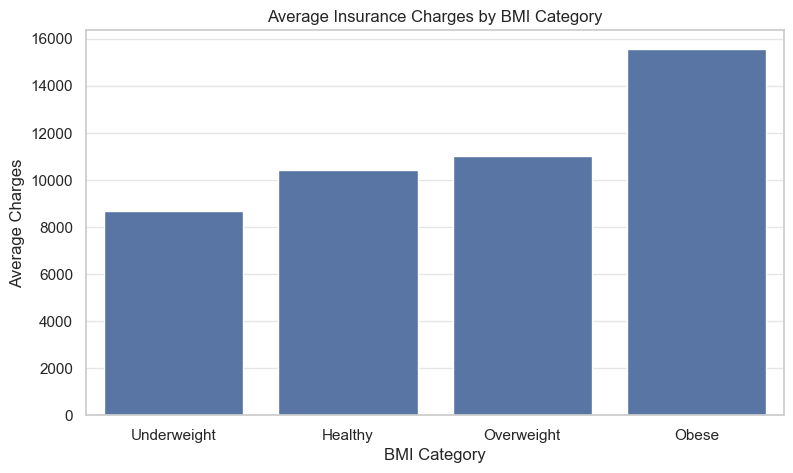

In [9]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df,
    x="bmi_category",
    y="charges",
    estimator="mean",
    errorbar=None,
    order=bmi_order,
)
plt.title("Average Insurance Charges by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Average Charges")
plt.show()

## BMI vs Charges

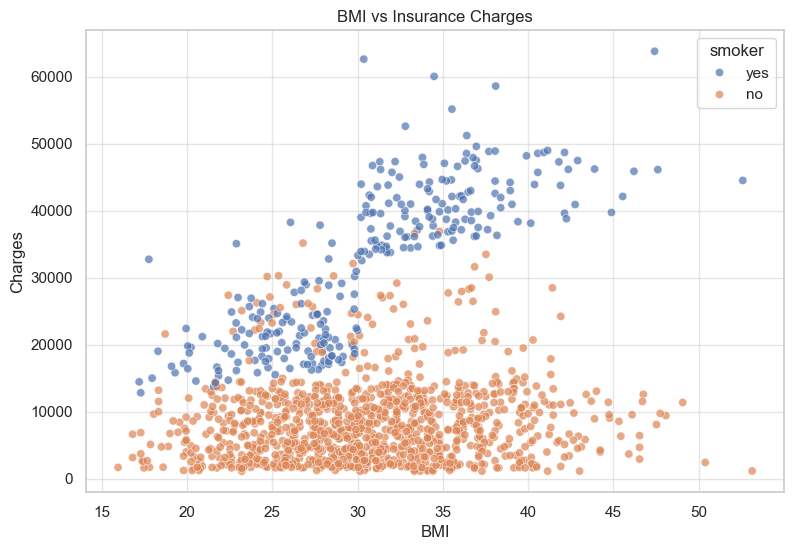

In [10]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=0.7)
plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

## Charges by Age Group

In [11]:
age_order = ["18-25", "26-35", "36-45", "46-55", "56-64"]

age_summary = (
    df.groupby("age_group", observed=False)["charges"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
    .reindex(age_order)
)

age_summary

,count,mean,median,min,max
age_group,,,,,
18-25,305,9111.43,2639.04,1121.87,44501.40
26-35,268,10495.16,4900.58,2302.30,58571.07
36-45,264,13493.49,7442.57,4399.73,62592.87
46-55,284,15986.90,10477.96,7147.10,63770.43
56-64,216,18795.99,13429.65,10577.09,52590.83


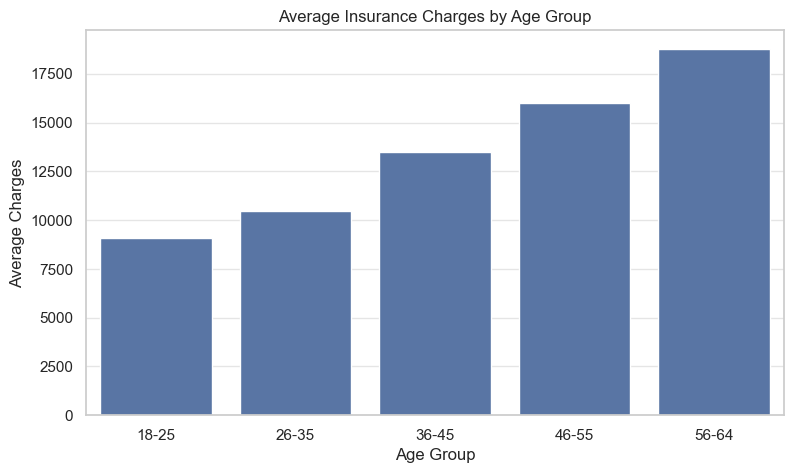

In [12]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="age_group", y="charges", estimator="mean", errorbar=None, order=age_order)
plt.title("Average Insurance Charges by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Charges")
plt.show()

## Charges by Region

In [13]:
region_summary = (
    df.groupby("region")["charges"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
    .sort_values("mean", ascending=False)
)

region_summary

,count,mean,median,min,max
region,,,,,
southeast,364,14735.41,9294.13,1121.87,63770.43
northeast,324,13406.38,10057.65,1694.80,58571.07
northwest,324,12450.84,8976.98,1621.34,60021.40
southwest,325,12346.94,8798.59,1241.56,52590.83


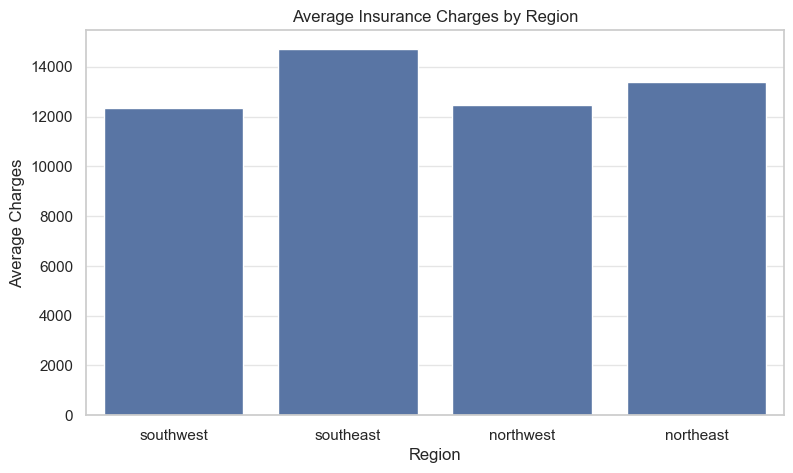

In [14]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="region", y="charges", estimator="mean", errorbar=None)
plt.title("Average Insurance Charges by Region")
plt.xlabel("Region")
plt.ylabel("Average Charges")
plt.show()

## Charges by Sex

In [15]:
sex_summary = (
    df.groupby("sex")["charges"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

sex_summary

,count,mean,median,min,max
sex,,,,,
female,662,12569.58,9412.96,1607.51,63770.43
male,675,13975.00,9377.90,1121.87,62592.87


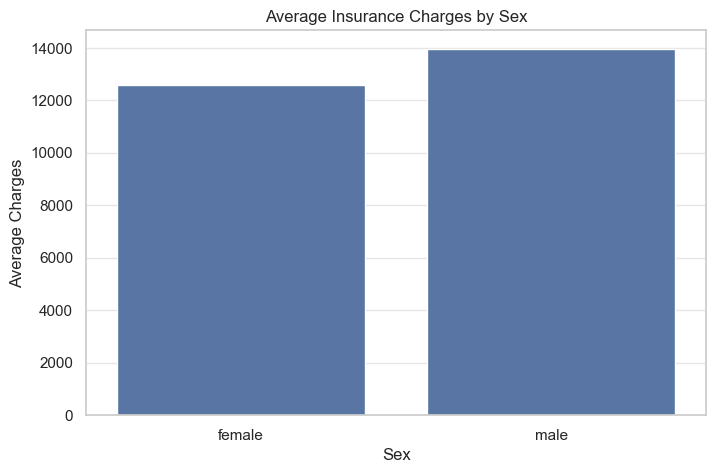

In [16]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="sex", y="charges", estimator="mean", errorbar=None)
plt.title("Average Insurance Charges by Sex")
plt.xlabel("Sex")
plt.ylabel("Average Charges")
plt.show()

## Correlation Analysis

In [17]:
numeric_cols = ["age", "bmi", "children", "charges", "is_smoker", "is_obese"]
correlation = df[numeric_cols].corr().round(2)
correlation

,age,bmi,children,charges,is_smoker,is_obese
age,1.00,0.11,0.04,0.30,-0.03,0.09
bmi,0.11,1.00,0.01,0.20,0.00,0.80
children,0.04,0.01,1.00,0.07,0.01,0.01
charges,0.30,0.20,0.07,1.00,0.79,0.20
is_smoker,-0.03,0.00,0.01,0.79,1.00,-0.00
is_obese,0.09,0.80,0.01,0.20,-0.00,1.00


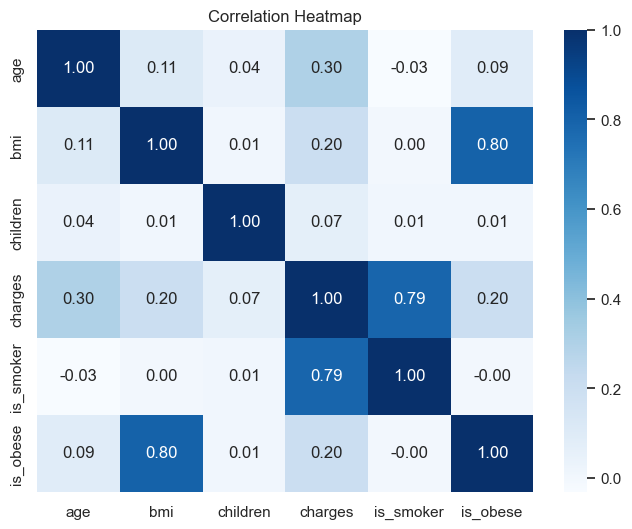

In [18]:
plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## SQL Check Using SQLite Database

In [20]:
conn = sqlite3.connect(DB_PATH)

query = """
SELECT
    smoker,
    COUNT(*) AS customer_count,
    ROUND(AVG(charges), 2) AS average_charge,
    ROUND(MIN(charges), 2) AS min_charge,
    ROUND(MAX(charges), 2) AS max_charge
FROM insurance
GROUP BY smoker
ORDER BY average_charge DESC;
"""

pd.read_sql_query(query, conn)

,smoker,customer_count,average_charge,min_charge,max_charge
0,yes,274,32050.23,12829.46,63770.43
1,no,1063,8440.66,1121.87,36910.61


In [21]:
query = """
SELECT
    region,
    COUNT(*) AS customer_count,
    ROUND(AVG(charges), 2) AS average_charge
FROM insurance
GROUP BY region
ORDER BY average_charge DESC;
"""

pd.read_sql_query(query, conn)

,region,customer_count,average_charge
0,southeast,364,14735.41
1,northeast,324,13406.38
2,northwest,324,12450.84
3,southwest,325,12346.94


In [22]:
conn.close()

## Final Insights and Recommendations

### Final Insight 1: Smoking status is the clearest cost driver

The analysis shows that smoker status has the strongest visible relationship with insurance charges. Patients who smoke have much higher average charges than customers who do not smoke. This pattern is stronger than the differences seen across region, sex, or number of children.

**Recommendation:** Insurance and healthcare organizations should prioritize smoking-related risk reduction. Practical actions could include smoking cessation programs, preventive care outreach, wellness incentives, and education around long-term medical cost impacts. If this analysis is used in a business setting, smoking status should be treated as one of the main segmentation fields for cost management.

### Final Insight 2: BMI category is an important secondary factor

BMI category also shows a meaningful pattern. Patients in the obese BMI category tend to have higher average charges than patients in lower BMI categories. The effect becomes especially important when BMI category is analyzed together with smoker status.

**Recommendation:** Organizations should support weight management and preventive health programs. This could include nutrition coaching, fitness incentives, annual health screenings, and early intervention for patients with elevated BMI. The goal should not be to label patients negatively, but to identify where preventive support may reduce long-term medical costs.

### Final Insight 3: Charges rise across older age groups

Average insurance charges generally increase as age group increases. Older patients tend to have higher charges, which is expected because healthcare needs often increase with age.

**Recommendation:** Age-based outreach should focus on preventive care and chronic condition management. Examples include routine screenings, annual wellness visits, medication adherence support, and early detection programs. These actions can help manage future costs while improving patient health outcomes.

### Final Insight 4: Region matters, but it is not the main driver

Regional differences exist, but they are smaller than the differences connected to smoking status, BMI category, and age group. Region may still reflect differences in healthcare access, local pricing, or patient mix.

**Recommendation:** Region should be used as a supporting analysis field rather than the main decision factor. If one region has consistently higher charges, the next step should be to investigate provider costs, healthcare access, and patient risk profiles in that region.


## Overall Conclusion

The strongest conclusion from this analysis is that smoking status is the most important visible factor associated with higher insurance charges. BMI category and age group are also important, especially when combined with smoking status. To combat these cost drivers, organizations should focus on preventive health programs, smoking cessation support, and weight management resources.

This project demonstrates how data cleaning, exploratory analysis, SQL checks, and dashboard visuals can work together to turn raw insurance data into practical business recommendations.